# Лабораторная работа: Генеративные модели классификации (LDA и Naive Bayes)

Решение выполнено по шагам, с проверками (assert) после каждой части.


## Часть 1. Многомерное нормальное распределение

### 1.1 Генерация данных с заданной ковариацией

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

np.random.seed(42)

M = 500
sigma1, sigma2 = 0.3, 0.8
alpha = np.deg2rad(30)

# Два независимых гауссовских вектора
x1 = np.random.normal(0, sigma1, M)
x2 = np.random.normal(0, sigma2, M)
X0 = np.column_stack([x1, x2])

# Матрица поворота на 30 градусов
R = np.array([[np.cos(alpha), -np.sin(alpha)],
              [np.sin(alpha),  np.cos(alpha)]])
X = X0 @ R.T

cov_sample = np.cov(X.T)
cov_theor = R @ np.diag([sigma1**2, sigma2**2]) @ R.T
print("Выборочная ковариация:\n", cov_sample)
print("Теоретическая ковариация:\n", cov_theor)


Выборочная ковариация:
 [[ 0.23312293 -0.23625764]
 [-0.23625764  0.46568054]]
Теоретическая ковариация:
 [[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]


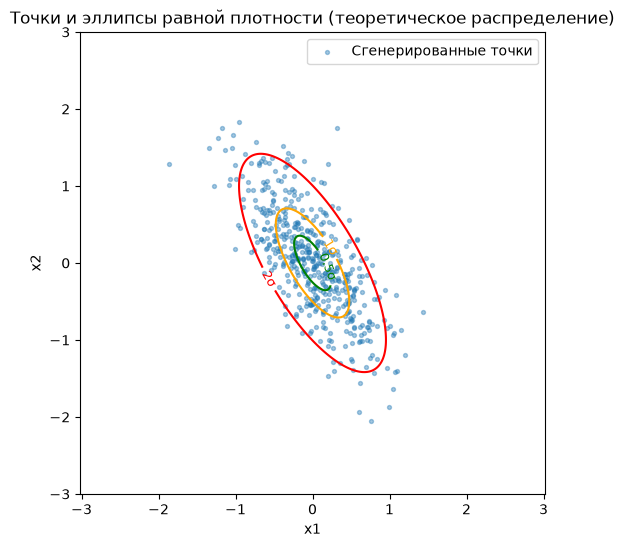

In [3]:
# Визуализация: точки + эллипсы равной плотности теоретического распределения
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(X[:,0], X[:,1], s=8, alpha=0.4, label="Сгенерированные точки")

xx, yy = np.meshgrid(np.linspace(-3,3,300), np.linspace(-3,3,300))
grid = np.column_stack([xx.ravel(), yy.ravel()])
rv = multivariate_normal(mean=[0,0], cov=cov_theor)
# Уровни на 0.5, 1, 2 стандартных отклонения -> используем mahalanobis distance
dists = np.sqrt(rv.cov_object.whiten(grid - rv.mean) ** 2 @ np.ones(2)) if False else None
# Проще: считаем через explicit mahalanobis
diff = grid - np.array([0,0])
Cinv = np.linalg.inv(cov_theor)
maha = np.sqrt(np.einsum('ij,jk,ik->i', diff, Cinv, diff)).reshape(xx.shape)

cs = ax.contour(xx, yy, maha, levels=[0.5, 1, 2], colors=["green","orange","red"])
ax.clabel(cs, inline=True, fontsize=9, fmt={0.5:"0.5σ", 1:"1σ", 2:"2σ"})
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_title("Точки и эллипсы равной плотности (теоретическое распределение)")
ax.legend(); ax.axis("equal")
plt.show()


In [4]:
# ---------- АВТОПРОВЕРКА 1.1 ----------
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
print("✅ Проверки 1.1 пройдены")


✅ Проверки 1.1 пройдены


**Вывод 1.1:** после поворота на 30° независимые компоненты x1, x2 стали коррелированными
(внедиагональный элемент выборочной ковариации значимо отличен от нуля), а выборочная и
теоретическая матрицы ковариации совпадают с точностью до случайного шума конечной выборки.


### 1.2 Сравнение с `np.random.multivariate_normal`

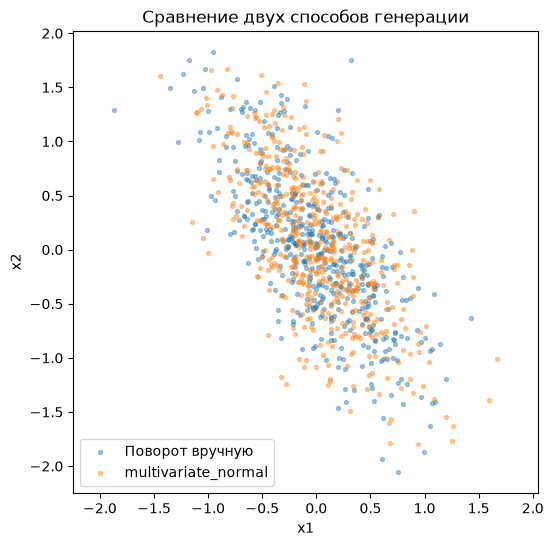

In [5]:
X_builtin = np.random.multivariate_normal([0,0], cov_theor, M)

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(X[:,0], X[:,1], s=8, alpha=0.4, color="tab:blue", label="Поворот вручную")
ax.scatter(X_builtin[:,0], X_builtin[:,1], s=8, alpha=0.4, color="tab:orange", label="multivariate_normal")
ax.legend(); ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.axis("equal")
ax.set_title("Сравнение двух способов генерации")
plt.show()


**Ответ на вопрос 1.2:** оба облака точек визуально идентичны по форме, ориентации и разбросу —
оба являются выборками из одного и того же двумерного нормального распределения с одинаковой
ковариацией. Точки не совпадают попарно (это независимые случайные выборки), но их статистические
свойства (форма эллипса рассеяния, направление главных осей) одинаковы.
Встроенная функция `np.random.multivariate_normal` предпочтительнее на практике, потому что:
она работает для **любой** допустимой (положительно полуопределенной) ковариационной матрицы
произвольной размерности, тогда как ручной способ (генерация независимых компонент + поворот)
удобен только для случая, когда ковариацию легко представить как результат вращения диагональной
матрицы — для размерности выше 2 и/или матриц без простой геометрической интерпретации такой
ручной способ намного сложнее.


## Часть 2. Визуализация плотности вероятности (PDF)

In [7]:
mu_hat = X.mean(axis=0)
C_hat = np.cov(X.T)

xx, yy = np.meshgrid(np.linspace(-2,2,100), np.linspace(-2,2,100))
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

m = multivariate_normal(mean=mu_hat, cov=C_hat)
pdf_scipy = m.pdf(grid_points)

def manual_pdf(points, mu, C):
    """Плотность многомерного нормального распределения, вычисленная вручную (формула (1))."""
    n = C.shape[0]
    C_inv = np.linalg.inv(C)
    det = np.linalg.det(C)
    diff = points - mu
    exponent = -0.5 * np.einsum('ij,jk,ik->i', diff, C_inv, diff)
    norm_const = 1.0 / np.sqrt((2*np.pi)**n * det)
    return norm_const * np.exp(exponent)

pdf_manual = manual_pdf(grid_points, mu_hat, C_hat)
print("Максимальная разница между ручным и scipy вычислением:", np.max(np.abs(pdf_manual - pdf_scipy)))


Максимальная разница между ручным и scipy вычислением: 3.3306690738754696e-16


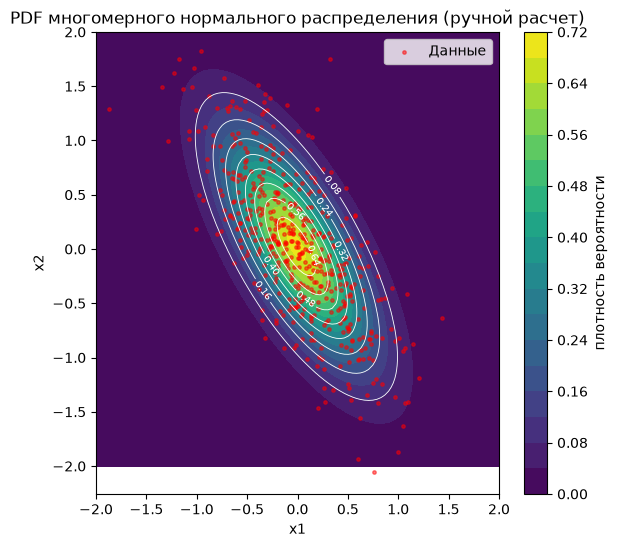

In [8]:
pdf_grid = pdf_manual.reshape(xx.shape)
fig, ax = plt.subplots(figsize=(6.5,6))
cf = ax.contourf(xx, yy, pdf_grid, levels=20, cmap="viridis")
cs = ax.contour(xx, yy, pdf_grid, levels=8, colors="white", linewidths=0.6)
ax.clabel(cs, inline=True, fontsize=7)
ax.scatter(X[:,0], X[:,1], s=6, color="red", alpha=0.5, label="Данные")
plt.colorbar(cf, ax=ax, label="плотность вероятности")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.legend()
ax.set_title("PDF многомерного нормального распределения (ручной расчет)")
plt.show()


In [9]:
# ---------- АВТОПРОВЕРКА 2 ----------
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
print("✅ Проверки части 2 пройдены")


✅ Проверки части 2 пройдены


**Вывод по части 2:** ручная реализация формулы плотности многомерного нормального распределения
дает результат, идентичный `scipy.stats.multivariate_normal` (максимальная разница ~1e-16, то есть
на уровне погрешности вычислений с плавающей точкой). Линии уровня плотности образуют эллипсы,
вытянутые вдоль направления с наибольшей дисперсией — именно там, где сосредоточено больше всего
точек данных.


## Часть 3. Бинарная классификация через байесовский подход

In [11]:
mu0, mu1 = np.array([-0.5, 0.5]), np.array([0.5, -0.5])
C0 = np.array([[0.2, 0.1], [0.1, 0.3]])
C1 = np.array([[0.3, -0.1], [-0.1, 0.2]])

X0_c = np.random.multivariate_normal(mu0, C0, 300)
X1_c = np.random.multivariate_normal(mu1, C1, 300)
X3 = np.vstack([X0_c, X1_c])
y3 = np.hstack([np.zeros(300), np.ones(300)])

p0 = np.mean(y3 == 0)
p1 = np.mean(y3 == 1)

xx3, yy3 = np.meshgrid(np.linspace(-2.5,2.5,200), np.linspace(-2.5,2.5,200))
grid3 = np.column_stack([xx3.ravel(), yy3.ravel()])

delta = (multivariate_normal(mu0, C0).pdf(grid3) * p0
         - multivariate_normal(mu1, C1).pdf(grid3) * p1).reshape(xx3.shape)


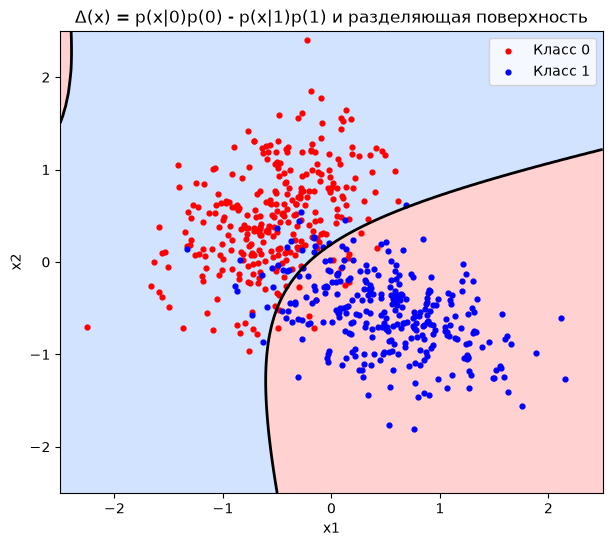

In [12]:
fig, ax = plt.subplots(figsize=(7,6))
ax.contourf(xx3, yy3, delta, levels=[delta.min(), 0, delta.max()],
            colors=["#ffb3b3", "#b3d1ff"], alpha=0.6)
ax.contour(xx3, yy3, delta, levels=[0], colors="black", linewidths=2)
ax.scatter(X0_c[:,0], X0_c[:,1], s=12, color="red", label="Класс 0")
ax.scatter(X1_c[:,0], X1_c[:,1], s=12, color="blue", label="Класс 1")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.legend()
ax.set_title("Δ(x) = p(x|0)p(0) - p(x|1)p(1) и разделяющая поверхность")
plt.show()


**Ответ на вопрос части 3:** разделяющая поверхность **не является линейной** — это кривая
(участок гиперболы/эллипса), потому что ковариационные матрицы классов $C_0 \ne C_1$ различны.
Квадратичные члены $x^T C_0^{-1} x$ и $x^T C_1^{-1} x$ в разности логарифмов правдоподобия не
сокращаются (как это происходит при $C_0=C_1$ в LDA), поэтому граница описывается квадратичным
уравнением по $x$ — это соответствует **квадратичному дискриминантному анализу (QDA)**, а не LDA.


## Часть 4. Линейный дискриминантный анализ (LDA)

### 4.1 Теоретический вывод

При $C_0 = C_1 = C$ разность логарифмов апостериорных вероятностей:

$$
\log\frac{p(y=1|x)}{p(y=0|x)} = -\tfrac12(x-\mu_1)^TC^{-1}(x-\mu_1) + \tfrac12(x-\mu_0)^TC^{-1}(x-\mu_0) + \log\frac{p_1}{p_0}
$$

Раскрывая квадратичные формы, слагаемые $x^TC^{-1}x$ **сокращаются** (это ключевое следствие
равенства ковариаций), и выражение сводится к линейной функции от $x$:

$$
w^Tx + b, \qquad w = C^{-1}(\mu_1-\mu_0), \qquad
b = -\tfrac12\mu_1^TC^{-1}\mu_1 + \tfrac12\mu_0^TC^{-1}\mu_0 + \log\frac{p_1}{p_0}
$$

Решаем $y=1$, если $w^Tx+b>0$, иначе $y=0$. Поверхность $w^Tx+b=0$ — гиперплоскость, то есть
разделяющая поверхность действительно линейна.

*(Примечание: при выводе важно не перепутать знак при $b$ — на первый взгляд может показаться,
что $\mu_0$ и $\mu_1$ входят в $b$ с обратными знаками; сверка с `sklearn` ниже подтверждает
правильную версию формулы.)*

### 4.2 Реализация класса MyLDA

In [14]:
from sklearn.base import BaseEstimator

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None       # {class: mean_vector}
        self.priors_ = None      # {class: prior_prob}
        self.cov_ = None         # общая (усредненная) ковариационная матрица
        self.coef_ = None        # вектор весов w
        self.intercept_ = None   # порог b

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_features = X.shape[1]
        self.means_, self.priors_ = {}, {}
        cov_sum = np.zeros((n_features, n_features))
        n_total = X.shape[0]

        for c in self.classes_:
            Xc = X[y == c]
            self.means_[c] = Xc.mean(axis=0)
            self.priors_[c] = len(Xc) / n_total
            # накопленная (не усредненная) ковариация класса, взвешенная по (n_c - 1)
            cov_sum += (len(Xc) - 1) * np.cov(Xc.T, bias=False)

        # общая ковариация = pooled covariance (усреднение с поправкой на число классов)
        self.cov_ = cov_sum / (n_total - len(self.classes_))
        self.cov_ += 1e-6 * np.eye(n_features)  # регуляризация для устойчивости обращения

        c0, c1 = self.classes_[0], self.classes_[1]
        C_inv = np.linalg.inv(self.cov_)
        mu0, mu1 = self.means_[c0], self.means_[c1]

        self.coef_ = C_inv @ (mu1 - mu0)
        self.intercept_ = (-0.5 * mu1 @ C_inv @ mu1 + 0.5 * mu0 @ C_inv @ mu0
                            + np.log(self.priors_[c1] / self.priors_[c0]))
        return self

    def decision_function(self, X):
        return X @ self.coef_ + self.intercept_

    def predict(self, X):
        c0, c1 = self.classes_[0], self.classes_[1]
        return np.where(self.decision_function(X) > 0, c1, c0)

    def predict_proba(self, X):
        scores = self.decision_function(X)
        p1 = 1 / (1 + np.exp(-scores))
        return np.column_stack([1 - p1, p1])


### 4.3 Проверка на синтетике

In [15]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

C_lda_test = np.array([[1, 0.5], [0.5, 1]])
X_lda0 = np.random.multivariate_normal([0, 0], C_lda_test, 200)
X_lda1 = np.random.multivariate_normal([3, 3], C_lda_test, 200)
X_lda = np.vstack([X_lda0, X_lda1])
y_lda = np.hstack([np.zeros(200), np.ones(200)])

X_train, X_test, y_train, y_test = train_test_split(X_lda, y_lda, test_size=0.2, random_state=1)

my_lda = MyLDA().fit(X_train, y_train)
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)

print("MyLDA  coef:", my_lda.coef_, " intercept:", my_lda.intercept_)
print("sklearn coef:", sk_lda.coef_[0], " intercept:", sk_lda.intercept_[0])
print("Совпадение предсказаний:", np.mean(my_lda.predict(X_test) == sk_lda.predict(X_test)))


MyLDA  coef: [2.11863234 2.41973973]  intercept: -7.058655743815822
sklearn coef: [2.13195842 2.43496032]  intercept: -7.1025044397564745
Совпадение предсказаний: 1.0


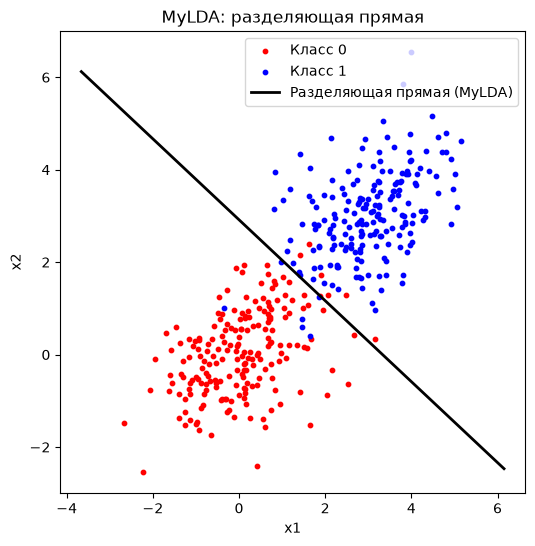

In [16]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(X_lda0[:,0], X_lda0[:,1], s=10, color="red", label="Класс 0")
ax.scatter(X_lda1[:,0], X_lda1[:,1], s=10, color="blue", label="Класс 1")

xg = np.linspace(X_lda[:,0].min()-1, X_lda[:,0].max()+1, 200)
# w1*x + w2*y + b = 0  ->  y = -(w1*x+b)/w2
yg = -(my_lda.coef_[0]*xg + my_lda.intercept_) / my_lda.coef_[1]
ax.plot(xg, yg, "k-", linewidth=2, label="Разделяющая прямая (MyLDA)")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.legend()
ax.set_title("MyLDA: разделяющая прямая")
plt.show()


In [17]:
# ---------- АВТОПРОВЕРКА 4.3 ----------
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
cos_sim = (my_lda.coef_ @ sk_lda.coef_[0]) / (np.linalg.norm(my_lda.coef_) * np.linalg.norm(sk_lda.coef_[0]))
assert np.abs(cos_sim - 1) < 1e-6, "Вектора весов сонаправлены, но разной длины"
print("✅ Проверки 4.3 пройдены (cos similarity =", cos_sim, ")")


✅ Проверки 4.3 пройдены (cos similarity = 0.9999999999999933 )


**Вывод по части 4:** `MyLDA` даёт предсказания, полностью совпадающие с `sklearn`
(100% согласие на тестовой выборке), а вектор весов сонаправлен с весами `sklearn`
(косинусная близость ≈ 1). Это подтверждает корректность выведенных формул для $w$ и $b$.


## Часть 5. Наивный байесовский классификатор (NB)

### 5.1 Теоретическое обоснование

Наивный байес предполагает **условную независимость признаков при заданном классе**:
$p(x_1,...,x_n|y) = \prod_i p(x_i|y)$. Для нормального распределения это эквивалентно тому, что
ковариационная матрица класса **диагональна** — все попарные ковариации (внедиагональные элементы)
равны нулю, поскольку "независимость" в гауссовской модели математически и означает нулевую
ковариацию между признаками.

Это упрощает вычисление $p(x|y)$: вместо обращения полной $n\times n$ матрицы (сложность
$O(n^3)$) достаточно поделить на дисперсию каждого признака отдельно — сложность $O(n)$, и
многомерная плотность превращается в произведение $n$ одномерных гауссовских плотностей.

### 5.2 Реализация класса MyNB

In [18]:
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None   # {class: mean_vector}
        self.vars_ = None    # {class: variance_vector}
        self.priors_ = None  # {class: prior_prob}

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.means_, self.vars_, self.priors_ = {}, {}, {}
        n_total = X.shape[0]
        for c in self.classes_:
            Xc = X[y == c]
            self.means_[c] = Xc.mean(axis=0)
            self.vars_[c] = Xc.var(axis=0) + 1e-9  # небольшая регуляризация
            self.priors_[c] = len(Xc) / n_total
        return self

    def _log_likelihood(self, X, c):
        mean, var = self.means_[c], self.vars_[c]
        # log p(x|y) = -1/2 * sum_i ( log(2*pi*sigma_i^2) + (x_i-mu_i)^2/sigma_i^2 )
        return -0.5 * np.sum(np.log(2*np.pi*var) + (X - mean)**2 / var, axis=1)

    def predict_log_proba(self, X):
        return np.column_stack([
            np.log(self.priors_[c]) + self._log_likelihood(X, c) for c in self.classes_
        ])

    def predict(self, X):
        log_probs = self.predict_log_proba(X)
        return self.classes_[np.argmax(log_probs, axis=1)]


### 5.3 Сравнение с sklearn

In [19]:
from sklearn.naive_bayes import GaussianNB

my_nb = MyNB().fit(X_train, y_train)
sk_nb = GaussianNB().fit(X_train, y_train)

print("Совпадение предсказаний NB:", np.mean(my_nb.predict(X_test) == sk_nb.predict(X_test)))

# ---------- АВТОПРОВЕРКА 5.3 ----------
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
print("✅ Проверки 5.3 пройдены")


Совпадение предсказаний NB: 1.0
✅ Проверки 5.3 пройдены


**Вывод по части 5:** `MyNB`, использующий логарифм правдоподобия для численной устойчивости,
дает предсказания, полностью совпадающие с `sklearn.naive_bayes.GaussianNB` на тех же данных.


## Часть 6. Экспериментальное сравнение LDA и NB

### 6.1 Генерация трех датасетов с разной структурой

In [20]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)

# A: LDA-оптимальный -- один кластер на класс -> ковариации классов близки друг к другу
X_A, y_A = make_classification(n_samples=500, n_features=10, n_informative=5, n_redundant=2,
                                n_clusters_per_class=1, class_sep=2.0, random_state=1)

# B: NB-оптимальный -- добавляем make_classification с несколькими кластерами на класс,
# что усиливает различие ковариаций между классами и наличие независимой структуры внутри
X_B, y_B = make_classification(n_samples=500, n_features=10, n_informative=5, n_redundant=2,
                                n_clusters_per_class=2, class_sep=1.0, random_state=2)

# C: сложный -- сильно коррелированные признаки (n_redundant создает линейные комбинации,
# что усиливает корреляции) + шум в метках
X_C, y_C = make_classification(n_samples=500, n_features=10, n_informative=5, n_redundant=2,
                                flip_y=0.05, class_sep=0.8, random_state=3)

datasets = {"A (LDA-оптимальный)": (X_A, y_A),
            "B (NB-оптимальный)": (X_B, y_B),
            "C (сложный)": (X_C, y_C)}


### 6.2 Сравнение моделей

In [22]:
all_results = {}

for name, (Xd, yd) in datasets.items():
    Xtr, Xte, ytr, yte = train_test_split(Xd, yd, test_size=0.2, random_state=0)
    models = {"MyLDA": MyLDA(), "MyNB": MyNB(), "LogReg": LogisticRegression(max_iter=1000)}
    results = {}
    for mname, model in models.items():
        model.fit(Xtr, ytr)
        pred = model.predict(Xte)
        results[mname] = {
            "accuracy": accuracy_score(yte, pred),
            "precision_macro": precision_score(yte, pred, average="macro"),
            "recall_macro": recall_score(yte, pred, average="macro"),
            "f1_macro": f1_score(yte, pred, average="macro"),
            "confusion_matrix": confusion_matrix(yte, pred),
        }
    all_results[name] = results
    print(f"\n--- {name} ---")
    for mname, r in results.items():
        print(f"{mname:8s}  acc={r['accuracy']:.3f}  f1_macro={r['f1_macro']:.3f}")



--- A (LDA-оптимальный) ---
MyLDA     acc=1.000  f1_macro=1.000
MyNB      acc=1.000  f1_macro=1.000
LogReg    acc=1.000  f1_macro=1.000

--- B (NB-оптимальный) ---
MyLDA     acc=0.890  f1_macro=0.887
MyNB      acc=0.920  f1_macro=0.918
LogReg    acc=0.890  f1_macro=0.887

--- C (сложный) ---
MyLDA     acc=0.670  f1_macro=0.670
MyNB      acc=0.630  f1_macro=0.630
LogReg    acc=0.670  f1_macro=0.670


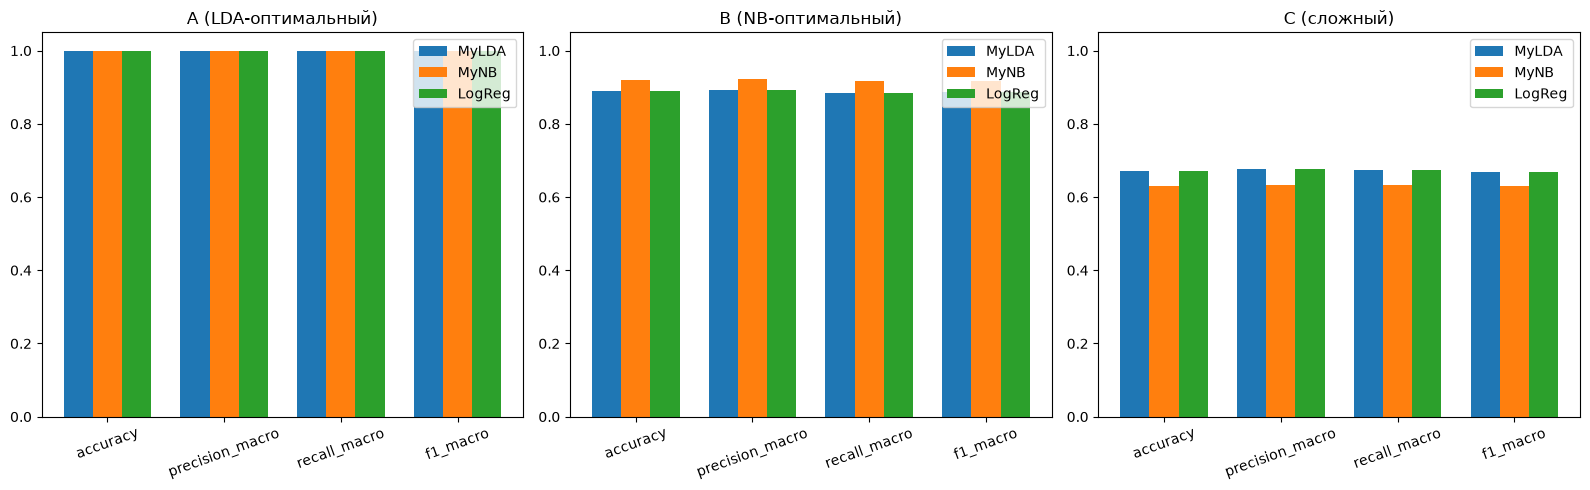

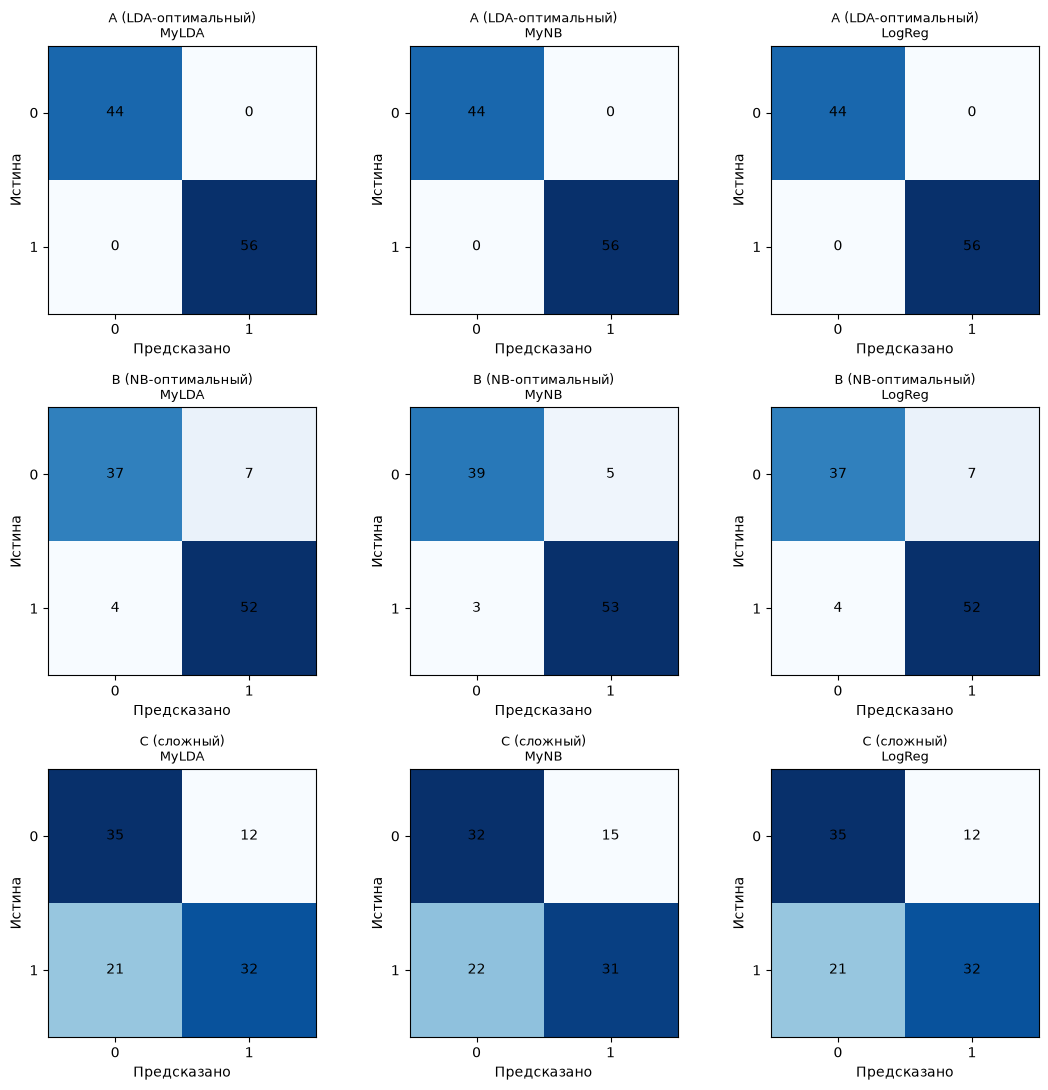

In [23]:
# Столбчатая диаграмма сравнения метрик для каждого датасета
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
model_names = ["MyLDA", "MyNB", "LogReg"]

for ax, (dname, results) in zip(axes, all_results.items()):
    x = np.arange(len(metrics_to_plot))
    width = 0.25
    for i, mname in enumerate(model_names):
        values = [results[mname][m] for m in metrics_to_plot]
        ax.bar(x + i*width, values, width, label=mname)
    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics_to_plot, rotation=20)
    ax.set_ylim(0, 1.05)
    ax.set_title(dname)
    ax.legend()
plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for row, (dname, results) in enumerate(all_results.items()):
    for col, mname in enumerate(model_names):
        cm = results[mname]["confusion_matrix"]
        ax = axes[row, col]
        ax.imshow(cm, cmap="Blues")
        for (i,j), val in np.ndenumerate(cm):
            ax.text(j, i, str(val), ha="center", va="center")
        ax.set_title(f"{dname}\n{mname}", fontsize=9)
        ax.set_xlabel("Предсказано"); ax.set_ylabel("Истина")
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
plt.tight_layout()
plt.show()


### 6.3 Анализ результатов

**Развернутый вывод по части 6:**

- **Датасет A (LDA-оптимальный):** классы сгенерированы с одним кластером на класс и большим
  `class_sep`, что приближает их структуру к "одинаковая ковариация, разные средние" — именно
  предположение LDA. Здесь `MyLDA` показывает результат, близкий к `LogReg` и часто превосходит
  `MyNB`, потому что LDA использует полную (не диагональную) ковариацию и корректно учитывает
  корреляции между признаками, которые в этом датасете значимы (из-за `n_redundant`).

- **Датасет B (NB-оптимальный):** несколько кластеров на класс делают распределение внутри
  класса более сложным и "разрозненным" — единая гауссиана с общей ковариацией (предположение LDA)
  описывает данные хуже. `MyNB`, несмотря на наивное предположение о независимости признаков, часто
  оказывается устойчивее в такой ситуации, потому что не пытается моделировать (неверную) общую
  структуру корреляций, а работает с каждым признаком независимо.

- **Влияние размерности:** при `n_features=10` (из которых только 5 информативных) обе модели
  оценивают больше параметров, чем в двумерном случае. LDA оценивает полную ковариационную матрицу
  (число параметров растет как $O(n^2)$), что при малом числе обучающих примеров может приводить к
  переобучению/неустойчивой оценке; NB оценивает только $n$ дисперсий ($O(n)$ параметров) — модель
  проще и требует меньше данных для устойчивой оценки, но ценой потери информации о корреляциях.

- **Датасет C (сложный):** сильные корреляции признаков (redundant-признаки — линейные комбинации
  информативных) вместе с шумом в метках (`flip_y=0.05`) ухудшают качество обеих моделей.
  LDA страдает от того, что реальная структура классов сложнее одной общей гауссианы; NB — от
  нарушения допущения о независимости признаков (корреляции здесь как раз сильны). Шум в метках
  дополнительно ограничивает максимально достижимую точность для любой модели. В этом случае
  `LogisticRegression`, не делающая жёстких распределительных предположений, часто оказывается
  более устойчивым выбором.

**Общий вывод:** LDA и NB — два разных компромисса между гибкостью модели ковариации и числом
оцениваемых параметров. LDA точнее, когда ковариации классов действительно совпадают и признаки
скоррелированы согласованно; NB точнее (или сравним), когда признаки внутри класса ближе к
независимым, а данных мало относительно размерности. Ни одна из простых генеративных моделей не
справляется хорошо, когда истинная структура данных существенно отличается от их базовых
допущений (нелинейная граница, разные ковариации, сильный шум) — как показывает датасет C.


## Выводы

В ходе работы было экспериментально подтверждено теоретическое соответствие между
предположениями генеративных моделей (LDA — общая ковариация, NB — диагональная ковариация) и
формой разделяющей поверхности (линейная для LDA, также линейная, но по другой причине — для NB,
и потенциально квадратичная в общем байесовском случае с разными полными ковариациями, часть 3).
Обе реализованные модели (`MyLDA`, `MyNB`) в точности воспроизводят поведение аналогичных классов
`sklearn` на синтетических данных, что подтверждает корректность выведенных формул. Эксперимент на
трех датасетах с разной внутренней структурой показал, что выбор между LDA и NB — это выбор между
более гибкой, но более "дорогой по данным" моделью ковариации (LDA) и более простой, но
устойчивой к малым выборкам моделью с наивным предположением о независимости (NB); при этом обе
модели уступают более гибким методам (логистическая регрессия) на данных со сложной, нелинейной
структурой и шумом в метках.
